In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PHASE 0: Data Loading

In [29]:
df = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\raw\chennai_pg_dataset.csv')

df.head()

,id,title,latitude,longitude,locality,address,gender,available_for,transit_score,lifestyle_score,...,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,gate_closing_time,smoking_allowed,guardian_required,nonveg_allowed
0,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
1,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
2,8aa9ba0d9ef7b08b019ef7beaaeb030e,PG for Boys in Anbu Homoeopathy And Acupunctur...,12.892600,80.114600,Perungalathur,"ramasamy nagar , Alapakkam, Anbu Homoeopathy A...",MALE,Both,5.7,4.1,...,True,True,True,True,True,True,NaN,True,True,False
3,8a9fae838be6a66a018be7e0229327a9,PG for Boys in Perungalathur,12.905105,80.095660,Perungalathur,", Gateway Office Parks Rd near Perungalathur P...",MALE,Both,NaN,NaN,...,False,False,False,False,False,False,NaN,False,False,False
4,8a9fb38499ce0d630199ce1448fd00e1,PG for Boys in Old Perungalathur,12.918673,80.081292,Shanthi Nagar,Parvathi Nagar near ( GANAPATHY MEN'S HOSTEL ...,MALE,Both,5.9,9.1,...,False,False,False,False,False,False,NaN,False,False,False


# PHASE 1: SANITY CHECK

- Check Coloumn types
- Count Nulls
- Check the datatypes

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1783 entries, 0 to 1782
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1783 non-null   str    
 1   title               1783 non-null   str    
 2   latitude            1783 non-null   float64
 3   longitude           1783 non-null   float64
 4   locality            1783 non-null   str    
 5   address             1783 non-null   str    
 6   gender              1783 non-null   str    
 7   available_for       1783 non-null   str    
 8   transit_score       883 non-null    float64
 9   lifestyle_score     883 non-null    float64
 10  occupancy           1759 non-null   str    
 11  rent                1759 non-null   float64
 12  deposit             1759 non-null   float64
 13  attached_bathroom   1759 non-null   object 
 14  food_included       1783 non-null   bool   
 15  breakfast           1783 non-null   bool   
 16  lunch            

In [5]:
df.isnull().sum().value_counts(ascending=False).rename_axis('Missing Values').reset_index(name='Columns').head(10)

# the index is the number of missing values.
# The value is the number of columns.

,Missing Values,Columns
0,0,16
1,24,4
2,806,3
3,900,2
4,830,2
5,829,2
6,175,2
7,165,2
8,834,1
9,833,1


# PHASE 2: TARGET VARIABLE ANALYSIS

  *Understand about the target variable*   

In [3]:
df_target = df['rent']
df_target.describe()

count     1759.000000
mean      7207.355884
std       4126.793881
min          0.000000
25%       6000.000000
50%       7000.000000
75%       8500.000000
max      65000.000000
Name: rent, dtype: float64

# Quick Visualization check for outliers

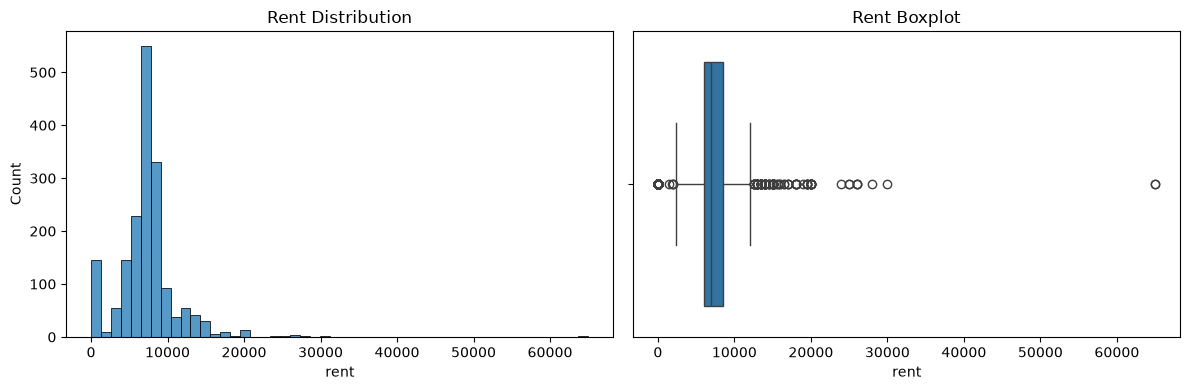

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sns.histplot(
    data=df,
    x='rent',
    bins=50,
    ax = axes[0]
)
axes[0].set_title("Rent Distribution")

# Boxplot
sns.boxplot(
    data = df,
    x = 'rent',
    ax = axes[1]
)
axes[1].set_title("Rent Boxplot")

plt.tight_layout()
plt.show()